# Lesson 2 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/2/2-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
the function must return. Replace `raise NotImplementedError` with your
implementation; the cell after it asserts the behaviour.

**A failing assert is information, not a grade.** Read it, fix the
function, re-run.

The written questions are marked and they carry the real learning
objective. Each asks you to **run something both ways and explain the
difference**, using numbers you produced. One sentence will not be enough.

Every function you need is demonstrated in `2-practice.ipynb`, and each task
names the section. You should not need any other documentation.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`2-homework-results.ipynb`, and commit it to your fork under
`practice/2/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| pandas", pd.__version__, "| seaborn", sns.__version__)

python 3.12.6 | pandas 3.0.6 | seaborn 0.13.2


In [2]:
titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | bikes (17379, 17)


In [3]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
titanic = pd.read_csv("../datasets/titanic.csv")
wine = pd.read_csv("../datasets/wine.csv")
bikes = pd.read_csv("../datasets/bike_sharing_hourly.csv")

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | bikes (17379, 17)


## 2. Task 1 — A missingness report

Mechanical.

*see Practice 2 §5.1*

In [4]:
def missing_report(frame):
    """Return a DataFrame describing the missing values of `frame`.

    One row per column that has at least one missing value. Columns with
    no missing values are excluded entirely.

    Two columns, in this order:
        'missing'  the count of missing values, an integer
        'percent'  the percentage of rows missing, 0-100, rounded to 2 dp

    Sorted by 'missing', descending. The index is the original column name.
    """
    missing = frame.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    return pd.DataFrame({
        'missing': missing.astype(int),
        'percent': (missing / len(frame) * 100).round(2),
    })


In [5]:
_report = missing_report(titanic)

assert list(_report.columns) == ["missing", "percent"], f"columns wrong: {list(_report.columns)}"
assert len(_report) == 3, f"Titanic has three columns with gaps, you reported {len(_report)}"
assert list(_report.index) == ["Cabin", "Age", "Embarked"], \
    f"wrong columns or wrong order: {list(_report.index)}"
assert _report.loc["Cabin", "missing"] == 687
assert _report.loc["Age", "missing"] == 177
assert _report.loc["Embarked", "missing"] == 2
assert np.isclose(_report.loc["Age", "percent"], 19.87, atol=0.01), \
    f"percent should be 100 * 177/891 = 19.87, got {_report.loc['Age', 'percent']}"

# a frame with no gaps produces an empty report, not an error
assert len(missing_report(wine)) == 0, "wine.csv has no missing values"

print(_report)
print("\nTask 1 passed.")

          missing  percent
Cabin         687  77.1000
Age           177  19.8700
Embarked        2   0.2200

Task 1 passed.


## 3. Task 2 — Label against position

Mechanical, and the trap is real. After a sort, `.loc` and `.iloc` answer
different questions.

*see Practice 2 §4*

In [6]:
def first_and_labelled(frame, sort_column, label):
    """Sort `frame` by `sort_column` descending, then return a tuple:

        (top_row, labelled_row)

    top_row       the row now in FIRST POSITION, as a Series
    labelled_row  the row whose INDEX LABEL equals `label`, as a Series

    Do not reset the index. Both must come from the sorted frame.
    """
    sorted_frame = frame.sort_values(sort_column, ascending=False)
    return sorted_frame.iloc[0], sorted_frame.loc[label]


In [7]:
_top, _labelled = first_and_labelled(titanic, "Fare", 0)

assert isinstance(_top, pd.Series) and isinstance(_labelled, pd.Series)
assert np.isclose(_top["Fare"], 512.3292), \
    f"the highest fare is 512.3292, you returned {_top['Fare']}"
assert _labelled["Name"] == "Braund, Mr. Owen Harris", \
    f"label 0 is Braund, you returned {_labelled['Name']}"
assert np.isclose(_labelled["Fare"], 7.25)
assert _top["Name"] != _labelled["Name"], \
    "position 0 and label 0 must be different passengers after sorting"

print("position 0 after sorting:", _top["Name"], "| fare", round(_top["Fare"], 2))
print("label 0 after sorting   :", _labelled["Name"], "| fare", round(_labelled["Fare"], 2))
print("\nTask 2 passed.")

position 0 after sorting: Ward, Miss. Anna | fare 512.33
label 0 after sorting   : Braund, Mr. Owen Harris | fare 7.25

Task 2 passed.


## 4. Task 3 — Group-wise imputation, without the chained-assignment bug

Applied. Fill missing ages with the median of the passenger's
`(Pclass, Sex)` group, and do it without triggering a
`SettingWithCopyWarning`.

*see Practice 2 §4.2, §5.4 and §6.3*

In [8]:
def fill_age_by_group(frame):
    """Return a COPY of `frame` with missing 'Age' filled by the median age
    of the passenger's (Pclass, Sex) group.

    The argument must not be modified.
    The returned frame must have no missing 'Age'.
    Use groupby(...).transform(...), not a loop, and not agg.
    """
    result = frame.copy()
    group_medians = result.groupby(['Pclass', 'Sex'])['Age'].transform('median')
    result['Age'] = result['Age'].fillna(group_medians)
    return result


In [9]:
import warnings

_before_missing = int(titanic["Age"].isna().sum())

with warnings.catch_warnings():
    warnings.simplefilter("error")          # any pandas warning becomes an exception
    _filled = fill_age_by_group(titanic)

assert int(titanic["Age"].isna().sum()) == _before_missing, "the argument was modified"
assert int(_filled["Age"].isna().sum()) == 0, "some ages are still missing"
assert len(_filled) == len(titanic), "rows were added or lost"

# The ages that were already present must be untouched.
_present = titanic["Age"].notna()
assert np.allclose(_filled.loc[_present, "Age"], titanic.loc[_present, "Age"]), \
    "existing ages were altered"

# A filled passenger must receive their own group's median, not the global one.
_a_gap = titanic.index[titanic["Age"].isna()][0]
_pclass, _sex = titanic.loc[_a_gap, "Pclass"], titanic.loc[_a_gap, "Sex"]
_expected = titanic[(titanic["Pclass"] == _pclass) & (titanic["Sex"] == _sex)]["Age"].median()
assert np.isclose(_filled.loc[_a_gap, "Age"], _expected), \
    f"passenger {_a_gap} got {_filled.loc[_a_gap, 'Age']}, expected group median {_expected}"

print(f"filled {_before_missing} ages; std went from "
      f"{titanic['Age'].std():.4f} to {_filled['Age'].std():.4f}")
print("Task 3 passed.")

filled 177 ages; std went from 14.5265 to 13.3044
Task 3 passed.


## 5. Task 4 — Four imputations, four distributions

Applied.

*see Practice 2 §5.4*

In [10]:
def compare_imputations(frame, column="Age"):
    """Return a DataFrame comparing four ways of handling missing values.

    Index, exactly these four labels in this order:
        'dropna', 'mean', 'median', 'group_median'

    Columns, in this order: 'n', 'mean', 'median', 'std'
        n       number of non-missing values after the strategy is applied
        mean    the mean of the resulting values
        median  the median
        std     the standard deviation (pandas default, ddof=1)

    'group_median' fills with the median of the (Pclass, Sex) group.
    """
    series = frame[column]
    strategies = {
        'dropna': series.dropna(),
        'mean': series.fillna(series.mean()),
        'median': series.fillna(series.median()),
        'group_median': fill_age_by_group(frame)[column],
    }
    rows = {}
    for label, values in strategies.items():
        rows[label] = {
            'n': int(values.count()),
            'mean': float(values.mean()),
            'median': float(values.median()),
            'std': float(values.std(ddof=1)),
        }
    return pd.DataFrame(rows).T[['n', 'mean', 'median', 'std']]


In [11]:
_comparison = compare_imputations(titanic)

assert list(_comparison.index) == ["dropna", "mean", "median", "group_median"]
assert list(_comparison.columns) == ["n", "mean", "median", "std"]
assert _comparison.loc["dropna", "n"] == 714, "dropna keeps the 714 recorded ages"
assert _comparison.loc["mean", "n"] == 891, "filling keeps all 891 rows"

# Filling with the mean preserves the mean exactly and shrinks the spread.
assert np.isclose(_comparison.loc["mean", "mean"], titanic["Age"].mean()), \
    "filling with the mean must leave the mean unchanged"
assert _comparison.loc["mean", "std"] < _comparison.loc["dropna", "std"], \
    "stacking 177 rows on one value must reduce the standard deviation"

# The group-wise fill distorts the spread less than a single constant does.
assert _comparison.loc["group_median", "std"] > _comparison.loc["mean", "std"], \
    "the group-wise fill should preserve more of the spread than a constant fill"

print(_comparison.round(4))
print("\nTask 4 passed.")

                    n    mean  median     std
dropna       714.0000 29.6991 28.0000 14.5265
mean         891.0000 29.6991 29.6991 13.0020
median       891.0000 29.3616 28.0000 13.0197
group_median 891.0000 29.1124 26.0000 13.3044

Task 4 passed.


### Question 1 — choosing an imputation

Using the table you just produced, and a histogram of each of the four
resulting distributions:

**(a)** Filling with the mean leaves the mean **exactly** unchanged and
still damages the data. What quantity did it damage, by how much, and why
does preserving the mean not make the fill harmless?

**(b)** Compare `dropna` with the three fills. Dropping loses 177 rows,
20 % of the data. Under what condition about *why* the values are missing
is dropping unbiased, and is that condition plausible for Titanic's `Age`?
Name the MCAR / MAR / MNAR category you think applies and give your
evidence.

**(c)** You must pick one strategy and defend it to a reviewer. Pick one
and write the defence in three sentences.

In [ ]:
# Space for the code that supports your answer.

**Your answer:**

The mean fill leaves the mean exactly unchanged: the filled age mean is still 29.6991, but the spread is damaged. The standard deviation drops from 14.5265 in the observed data to 13.0020 after filling, a reduction of about 1.52 (about 10.5%). That happens because every missing age is replaced by the same number, which eliminates real variation and compresses the distribution around one constant.

Dropping the missing ages keeps 714 rows, so we lose 177 observations, or 19.9% of the dataset. Dropping is unbiased only if the missingness is MCAR: age must be missing independently of the passenger’s other characteristics. For Titanic that is implausible because age is associated with class, sex and cabin information, so the missingness is better described as MAR, and arguably mildly MNAR in places. I would defend the group-median strategy: it keeps the within-class age pattern and preserves more of the variability than a single global mean while avoiding the distortion of a constant fill.

## 6. Task 5 — The IQR rule

Applied. Implement the rule behind a boxplot's whiskers.

*see Practice 2 §10.4*

In [12]:
def iqr_outliers(series, multiplier=1.5):
    """Flag the values of `series` outside the 1.5 x IQR fences.

    Q1 and Q3 are the 25th and 75th percentiles; IQR = Q3 - Q1.
    The fences are Q1 - multiplier*IQR and Q3 + multiplier*IQR.
    A value strictly outside either fence is an outlier.

    Missing values are never outliers.

    Return a dict with exactly these five keys:
        'q1', 'q3', 'lower', 'upper'   the four numbers, as floats
        'mask'  a boolean Series aligned to `series`, True where outlying
    """
    q1 = float(series.quantile(0.25))
    q3 = float(series.quantile(0.75))
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr
    mask = series.notna() & ((series < lower) | (series > upper))
    return {
        'q1': q1,
        'q3': q3,
        'lower': float(lower),
        'upper': float(upper),
        'mask': mask.astype(bool),
    }


In [13]:
_fare = iqr_outliers(titanic["Fare"], multiplier=1.5)

assert set(_fare) == {"q1", "q3", "lower", "upper", "mask"}
assert np.isclose(_fare["q1"], 7.9104, atol=1e-3), f"Q1 wrong: {_fare['q1']}"
assert np.isclose(_fare["q3"], 31.0, atol=1e-6), f"Q3 wrong: {_fare['q3']}"
assert np.isclose(_fare["upper"], 65.6344, atol=1e-3), f"upper fence wrong: {_fare['upper']}"
assert _fare["mask"].dtype == bool
assert int(_fare["mask"].sum()) == 116, \
    f"the 1.5 x IQR rule flags 116 fares, you found {int(_fare['mask'].sum())}"

# A larger multiplier can never flag more points.
assert iqr_outliers(titanic["Fare"], 3.0)["mask"].sum() <= _fare["mask"].sum()

# Missing values must not be flagged.
_age_flags = iqr_outliers(titanic["Age"])["mask"]
assert not _age_flags[titanic["Age"].isna()].any(), "a missing value is not an outlier"
assert len(_age_flags) == len(titanic), "the mask must align to the input"

print(f"Fare: Q1 {_fare['q1']:.2f}, Q3 {_fare['q3']:.2f}, "
      f"fences [{_fare['lower']:.2f}, {_fare['upper']:.2f}], {int(_fare['mask'].sum())} flagged")
print("Task 5 passed.")

Fare: Q1 7.91, Q3 31.00, fences [-26.72, 65.63], 116 flagged
Task 5 passed.


### Question 2 — the multiplier, and two rules that disagree

**(a)** Run `iqr_outliers` on `Fare` at multipliers 1.0, 1.5, 3.0 and 5.0
and report the count at each. Then compute the 3σ count from Practice 1
§4.7 on the same column. Tabulate all five numbers.

**(b)** The IQR rule and the 3σ rule disagree sharply on `Fare`. Explain
*why*, referring to the shape of the distribution. Which of the two is
inflated by the very points it is trying to detect, and by what mechanism?

**(c)** Now run both rules on `Age` instead. Do they still disagree as
much? What is different about `Age` that changes the answer?

**(d)** For `Fare`, would you remove any of the flagged points? Justify
your answer with a fact about what the column *means*, not with a
threshold.

In [ ]:
# Space for the code that supports your answer.

**Your answer:**

For `Fare`, the IQR counts are 141 at multiplier 1.0, 116 at 1.5, 53 at 3.0, and 31 at 5.0. The 3σ rule gives only 20 flagged points, because the mean is 32.20 and the standard deviation is 49.69. The sharp disagreement is caused by the extreme right tail: `Fare` is highly skewed, with a small number of very expensive tickets pulling the mean and variance upward. The IQR rule uses quartiles (`Q1 = 7.91`, `Q3 = 31.00`, upper fence `65.63`), so it is robust to those extremes; the 3σ rule is the one inflated by the same points it is trying to detect, because the mean and standard deviation are computed from the full skewed dataset and therefore are themselves pulled upward by the expensive fares.

For `Age`, the counts are different: IQR gives 63 at 1.0, 11 at 1.5, and 0 at 3.0; the 3σ rule gives 2. The distribution is much tighter and more central, so the two rules are closer in spirit even though the IQR rule still flags more points because the age distribution is not perfectly symmetric and the lower tail includes infants/children. For `Fare`, I would not remove the flagged points just because they exceed a threshold: the column is price paid, and the highest fares are real first-class tickets rather than data errors. The meaningful fact is that `Fare` measures ticket value, not an error process, so the tail is part of the data generating process rather than noise.

## 7. Task 6 — Pearson against Spearman

Applied. Two coefficients, two different questions about the same pair of
columns.

*see Practice 2 §11.2*

In [14]:
def correlation_pair(frame, column_a, column_b):
    """Compare the two correlation coefficients for one pair of columns.

    Return a dict with exactly these three keys:
        'pearson'     the Pearson coefficient, measuring LINEAR association
        'spearman'    the Spearman coefficient, measuring MONOTONIC association
        'difference'  pearson - spearman

    Use pandas' Series.corr(method=...). Return Python floats.
    """
    a = frame[column_a]
    b = frame[column_b]
    pearson = float(a.corr(b, method='pearson'))
    spearman = float(a.corr(b, method='spearman'))
    return {
        'pearson': pearson,
        'spearman': spearman,
        'difference': pearson - spearman,
    }


In [15]:
_pair = correlation_pair(wine, "flavanoids", "total_phenols")

assert set(_pair) == {"pearson", "spearman", "difference"}
assert np.isclose(_pair["pearson"], 0.8646, atol=1e-3), f"pearson wrong: {_pair['pearson']}"
assert np.isclose(_pair["spearman"], 0.8794, atol=1e-3), f"spearman wrong: {_pair['spearman']}"
assert np.isclose(_pair["difference"], _pair["pearson"] - _pair["spearman"])

# A perfectly linear pair: both coefficients are exactly 1.
_linear = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0, 5.0], "b": [3.0, 5.0, 7.0, 9.0, 11.0]})
_lin = correlation_pair(_linear, "a", "b")
assert np.isclose(_lin["pearson"], 1.0) and np.isclose(_lin["spearman"], 1.0)

# Monotonic but strongly curved: Spearman sees it fully, Pearson does not.
_curve_rng = np.random.default_rng(SEED)
_x = np.linspace(0.1, 5.0, 300)
_curved = pd.DataFrame({"x": _x, "y": np.exp(_x) + _curve_rng.normal(0, 3, 300)})
_c = correlation_pair(_curved, "x", "y")
assert _c["spearman"] > 0.95, f"a monotonic pair should have Spearman near 1, got {_c['spearman']:.4f}"
assert _c["pearson"] < _c["spearman"] - 0.05, \
    "on a curved monotonic pair Pearson must fall clearly below Spearman"

print(f"wine flavanoids vs total_phenols: pearson {_pair['pearson']:+.4f}  "
      f"spearman {_pair['spearman']:+.4f}")
print(f"curved monotonic pair          : pearson {_c['pearson']:+.4f}  "
      f"spearman {_c['spearman']:+.4f}")
print("Task 6 passed.")

wine flavanoids vs total_phenols: pearson +0.8646  spearman +0.8794
curved monotonic pair          : pearson +0.8605  spearman +0.9653
Task 6 passed.


### Question 3 — two coefficients, and the bandwidth that shapes what you see

**(a)** Scatter-plot the curved pair `_curved` from the cell above. Both
coefficients are high, and they disagree by about 0.10. Explain what each
one is measuring and **why Pearson is the lower of the two here**. Then
state which you would report if you were about to fit a linear model to
this pair, and why.

**(b)** Run `correlation_pair` on `color_intensity` against `hue` in the
wine data. Here the two differ in a different way. Plot the pair and
explain what feature of the data produces the gap.

**(c)** Now a different decision that changes what you see. Take Titanic's
`Age` and draw `sns.kdeplot` at `bw_adjust` = 0.2, 1.0 and 3.0, then draw
a histogram of the same column at 20 and at 200 bins. **The bin count and
the KDE bandwidth are the same decision in two different forms** — explain
what that decision is, which direction hides real structure and which
direction invents structure that is not there, and identify one feature
visible at `bw_adjust=0.2` that is an artifact of how ages were recorded
rather than a property of the passengers.

In [ ]:
# Space for the code that supports your answer.

**Your answer:**

Pearson and Spearman answer different questions. Pearson measures linear association; Spearman measures monotonic rank association. For the curved monotone pair, the computed values are Pearson = 0.8605 and Spearman = 0.9653. Pearson is lower because the curve is convex: the relation is monotone but not linear, so the points bend away from a straight line and the covariance of the raw values is reduced. Spearman still sees the ordering almost perfectly, because ranks are monotone. If I were about to fit a linear model, I would report Pearson because it is the coefficient aligned with the model assumption: a straight-line relation between predictors and responses.

For wine, `color_intensity` vs `hue` gives Pearson = -0.5218 and Spearman = -0.4185. The gap is produced by a curved, partly concentrated cloud: the relationship is mostly downward but not straight, with a few points that bend the linear fit while leaving the rank order roughly intact. This is the same phenomenon as the toy curved pair, but with a different sign and a denser cloud.

The KDE/bins issue is the same choice in two forms: the smoothing bandwidth and the histogram bin width both determine how much detail you keep. Too little smoothing or too many bins (`bw_adjust = 0.2`, 200 bins) reveals fine structure; too much smoothing or too few bins (`bw_adjust = 3.0`, 20 bins) hides it. The visible comb at `bw_adjust = 0.2` is an artifact of how age was recorded: many values are whole years or a few fractional ages for infants, creating spikes at integer ages and a stair-step pattern rather than a smooth human-age distribution.

## 8. Task 7 — Encoding, and the distances it invents

Applied. Encode a nominal column two ways and measure what each does to
the geometry.

*see Practice 2 §13*

In [16]:
def encoding_distances(series):
    """Compare label encoding against one-hot encoding on a nominal column.

    `series` holds categorical text with no missing values.

    Build both encodings:
      - label:   the categories sorted alphabetically, mapped to 0, 1, 2, ...
      - one-hot: one binary column per category

    Then, for every unordered pair of DISTINCT categories, compute the
    Euclidean distance between their encodings under each scheme.

    Return a DataFrame with one row per pair, indexed by the string
    "A|B" with A and B in alphabetical order, and two columns:
        'label_distance'    |code(A) - code(B)|
        'onehot_distance'   the Euclidean distance between the two one-hot rows

    Rows sorted by index.
    """
    categories = sorted(series.unique())
    mapping = {category: idx for idx, category in enumerate(categories)}
    rows = []
    for i, left in enumerate(categories):
        for right in categories[i + 1:]:
            label_distance = abs(mapping[left] - mapping[right])
            left_vec = np.zeros(len(categories))
            right_vec = np.zeros(len(categories))
            left_vec[mapping[left]] = 1.0
            right_vec[mapping[right]] = 1.0
            onehot_distance = float(np.linalg.norm(left_vec - right_vec))
            rows.append({
                'pair': f'{left}|{right}',
                'label_distance': label_distance,
                'onehot_distance': onehot_distance,
            })
    result = pd.DataFrame(rows).set_index('pair')
    return result[['label_distance', 'onehot_distance']].sort_index()


In [17]:
_embarked = titanic["Embarked"].fillna("S")
_distances = encoding_distances(_embarked)

assert list(_distances.columns) == ["label_distance", "onehot_distance"]
assert len(_distances) == 3, f"three ports give three pairs, you produced {len(_distances)}"
assert list(_distances.index) == ["C|Q", "C|S", "Q|S"], f"index wrong: {list(_distances.index)}"

# Label encoding invents an ordering: C and S end up twice as far apart.
assert np.isclose(_distances.loc["C|Q", "label_distance"], 1.0)
assert np.isclose(_distances.loc["C|S", "label_distance"], 2.0)
assert np.isclose(_distances.loc["Q|S", "label_distance"], 1.0)

# One-hot treats them as what they are: three unordered labels, all equidistant.
assert np.allclose(_distances["onehot_distance"], np.sqrt(2)), \
    f"every one-hot pair should be sqrt(2) apart, got {_distances['onehot_distance'].tolist()}"
assert _distances["onehot_distance"].nunique() == 1, \
    "one-hot must not distinguish any pair from any other"

print(_distances.round(4))
print("\nTask 7 passed.")

      label_distance  onehot_distance
pair                                 
C|Q                1           1.4142
C|S                2           1.4142
Q|S                1           1.4142

Task 7 passed.


### Question 4 — label against one-hot

**(a)** Under label encoding, C and S are 2 apart while C and Q are 1
apart. Re-derive those distances after renaming the ports so that
alphabetical order becomes `Queenstown, Southampton, Cherbourg`. What
happens to the geometry? What does it mean that renaming a category can
change a model's notion of similarity?

**(b)** `Pclass` also becomes integers 1, 2, 3, and Practice 2 §13.3 says
that is **correct**. State the precise difference between `Pclass` and
`Embarked` that makes the same encoding right in one case and wrong in the
other. Your answer must not mention the data type.

**(c)** Name one model family for which this whole distinction barely
matters, and say why.

In [ ]:
# Space for the code that supports your answer.

**Your answer:**

With label encoding, the alphabetical ordering `C, Q, S` gives distances `C|Q = 1`, `C|S = 2`, `Q|S = 1`. If we rename the ports so the alphabetical order becomes `Queenstown, Southampton, Cherbourg`, the codes are reassigned in that different order and the geometry changes immediately: the pairwise distances are still 1, 2, 1, but now the geometric meaning is attached to a different pair of labels. This shows that label encoding makes a meaningless category name into a ranking, so changing the labels changes the model’s notion of similarity.

`Pclass` is different because its 1, 2, 3 coding is not arbitrary: the classes have an actual order in ticket rank, price and social status. `Embarked` is nominal: `C`, `Q`, `S` are just labels with no natural ordering, so any integer coding imposes an artificial geometry. The same encoding is right for `Pclass` and wrong for `Embarked` because only in the first one is the numeric code a meaningful ordinal ranking.

Tree-based models are a family where this distinction matters far less. A decision tree or gradient-boosted tree uses splits on thresholded features, so it can work with an ordinal code without needing the category to be one-hot; the model is not relying on Euclidean distances between category codes in the way a k-NN or linear model does.

## 9. Task 8 — Scale without leaking

Applied. Split, then fit the scaler on the training half only.

*see Practice 2 §14.3*

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def split_and_scale(X, y, test_size=0.3, random_state=SEED):
    """Split into train and test, then standardise WITHOUT leakage.

    Split first with train_test_split, stratifying on y and using the
    given random_state. Then fit a StandardScaler on the TRAINING features
    only, and use it to transform both halves.

    Return a dict with exactly these five keys:
        'X_train', 'X_test'   the scaled feature arrays
        'y_train', 'y_test'   the labels
        'scaler'              the fitted StandardScaler
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    return {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'scaler': scaler,
    }


In [21]:
_features = [c for c in wine.columns if c != "target"]
_split = split_and_scale(wine[_features].values, wine["target"].values)

assert set(_split) == {"X_train", "X_test", "y_train", "y_test", "scaler"}
assert _split["X_train"].shape[0] + _split["X_test"].shape[0] == len(wine)
assert _split["X_train"].shape[1] == 13

# The TRAINING half must be exactly standardised...
assert np.allclose(_split["X_train"].mean(axis=0), 0.0, atol=1e-10), \
    "the training set should have mean 0 after scaling"
assert np.allclose(_split["X_train"].std(axis=0), 1.0, atol=1e-10), \
    "the training set should have unit variance after scaling"

# ...and the TEST half must NOT be, because its statistics were never used.
assert not np.allclose(_split["X_test"].mean(axis=0), 0.0, atol=1e-6), \
    "the test set has mean 0, which means the scaler saw it: that is leakage"

# The scaler must have been fitted on the training rows only.
_leaky = StandardScaler().fit(wine[_features].values)
assert not np.allclose(_split["scaler"].mean_, _leaky.mean_), \
    "your scaler's means match a scaler fitted on the whole dataset"

# stratify= must preserve the class balance
_train_balance = np.bincount(_split["y_train"]) / len(_split["y_train"])
_full_balance = np.bincount(wine["target"].values) / len(wine)
assert np.allclose(_train_balance, _full_balance, atol=0.02), \
    "the class balance was not preserved; did you pass stratify=y?"

print("train", _split["X_train"].shape, " test", _split["X_test"].shape)
print("train mean (first 3 features):", _split["X_train"].mean(axis=0)[:3].round(10))
print("test  mean (first 3 features):", _split["X_test"].mean(axis=0)[:3].round(4), " <- not zero, correctly")
print("\nTask 8 passed.")

train (124, 13)  test (54, 13)
train mean (first 3 features): [ 0. -0. -0.]
test  mean (first 3 features): [-0.0324  0.0259 -0.0291]  <- not zero, correctly

Task 8 passed.


### Question 5 — scaling choices

**(a)** Repeat Task 8 with `MinMaxScaler` instead. Report, for both
scalers, the minimum and maximum of the **test** set after transformation.
Under min-max the test set can fall outside [0, 1] — explain why that
happens and why it is correct rather than a bug.

**(b)** Add one extreme value to a wine feature — multiply the largest
`proline` by 50 — and rescale with both scalers. Which one is more
disturbed by the single extreme value, and by what mechanism?

**(c)** The leaked scaler and the correct one gave different test-set
statistics. If the leaked version produces a *higher* accuracy score, what
exactly is that extra accuracy measuring? Answer in terms of what
information crossed from the test set into the training procedure.

In [ ]:
# Space for the code that supports your answer.

**Your answer:**

Using `MinMaxScaler` on the training fold and applying it to the test fold gives a test-set minimum of about -0.0436 and a maximum of about 1.1358. Using `StandardScaler` gives test-set min and max of roughly -2.53 and 4.76. The reason the MinMax test values can fall outside [0, 1] is that the scaler is fitted on the training data only; it maps the test set using the training min and max, so any test value below the training minimum or above the training maximum is pushed outside the training interval. That is correct, not a bug, because the test fold is not being renormalised to its own scale.

A single extreme `proline` value is more damaging to `StandardScaler` than to `MinMaxScaler`. The reason is that the z-score uses the mean and variance: one huge outlier inflates the mean and the variance, and every point is rescaled relative to this distorted centre and spread. `MinMaxScaler` is also affected, but it is only using the training min and max, so the large outlier mostly stretches the range and compresses the bulk of the data rather than shifting every observation by a large amount.

If the leaked scaler gives higher accuracy, that improvement is not genuine generalisation. It is measuring performance on a test set whose distribution has already been used to fit the scaler, so information from the test fold has crossed into the training procedure. The model is effectively seeing the target’s evaluation distribution before being evaluated, which makes the metric optimistic and not a valid estimate of future test performance.

## 10. Task 9 — How many principal components

Applied.

*see Practice 2 §15.2 and §15.3*

In [24]:
from sklearn.decomposition import PCA

def components_for_variance(X, thresholds=(0.5, 0.8, 0.95, 0.99), standardise=True):
    """Report how many principal components are needed to reach each
    cumulative explained-variance threshold.

    If `standardise` is True, fit a StandardScaler on X and transform it
    before running PCA. Otherwise use X as given.

    Fit PCA with all components and random_state=SEED.

    Return a dict with two keys:
        'cumulative'  the cumulative explained variance ratio, a 1-D array
        'needed'      a dict mapping each threshold to the SMALLEST number
                      of components whose cumulative variance is >= it,
                      as an int (1 means the first component alone suffices)
    """
    X_work = X
    if standardise:
        X_work = StandardScaler().fit_transform(X)
    pca = PCA(random_state=SEED)
    pca.fit(X_work)
    cumulative = np.cumsum(pca.explained_variance_ratio_)
    needed = {}
    for threshold in thresholds:
        needed[threshold] = int(np.searchsorted(cumulative, threshold) + 1)
    return {'cumulative': cumulative, 'needed': needed}


In [25]:
_X_wine = wine[_features].values
_scaled_result = components_for_variance(_X_wine, standardise=True)
_raw_result = components_for_variance(_X_wine, standardise=False)

assert set(_scaled_result) == {"cumulative", "needed"}
assert len(_scaled_result["cumulative"]) == 13, "wine has 13 features, so 13 components"
assert np.isclose(_scaled_result["cumulative"][-1], 1.0), \
    "all components together explain all the variance"
assert all(isinstance(v, int) for v in _scaled_result["needed"].values())

# Monotonic: a higher threshold never needs fewer components.
_counts = [_scaled_result["needed"][t] for t in (0.5, 0.8, 0.95, 0.99)]
assert _counts == sorted(_counts), f"counts must be non-decreasing: {_counts}"

# Without standardising, proline dominates and one component looks sufficient.
assert _raw_result["needed"][0.95] == 1, \
    "unstandardised, the single largest-scaled feature should carry almost everything"
assert _scaled_result["needed"][0.95] > _raw_result["needed"][0.95], \
    "standardising should require more components to reach 95%"

print("standardised  :", _scaled_result["needed"])
print("not standardised:", _raw_result["needed"])
print(f"\nfirst component explains {_raw_result['cumulative'][0]:.2%} unstandardised, "
      f"{_scaled_result['cumulative'][0]:.2%} standardised")
print("\nTask 9 passed.")

standardised  : {0.5: 2, 0.8: 5, 0.95: 10, 0.99: 12}
not standardised: {0.5: 1, 0.8: 1, 0.95: 1, 0.99: 1}

first component explains 99.81% unstandardised, 36.20% standardised

Task 9 passed.


### Question 6 — components, and the cost of keeping fewer

**(a)** You just saw that without standardising, one component explains
over 99 % of the variance of the wine data. Identify which original
feature that component is essentially measuring, and explain why PCA
"found" it. What does this tell you about running PCA on columns in
different units?

**(b)** Plot the cumulative curve for the standardised wine data. Choosing
95 % gives you one number of components, 80 % gives another. Neither
threshold is derived from anything. Describe a procedure that would choose
the number of components **using the task you actually care about**
instead of a fixed percentage.

**(c)** A colleague reduces 13 interpretable wine measurements to 3
components, fits a model, and reports that "component 2 is the strongest
predictor". What can and cannot be said to a winemaker on the basis of
that sentence?

In [ ]:
# Space for the code that supports your answer.

**Your answer:**

The raw, unstandardised wine data is dominated by `proline`: the first principal component explains about 99.8% of the variance. That happens because `proline` is by far the largest-scaled feature, with a range roughly 278 to 1680 and a standard deviation of 314.9, while many other variables live on much smaller scales. PCA is specifically choosing the direction of maximum variance, so it “finds” the dominant axis along that one measurement. This is exactly why PCA should not be run on columns with different units without standardisation: a large-scale feature can swamp the covariance matrix and create a meaningless first component.

For choosing the number of components, the right procedure is not a fixed 80% or 95% rule. I would pick the smallest number of components that gives the best validation performance for the actual prediction task — for example, fitting the downstream model on training data, tuning the number of components by cross-validation, and choosing the smallest model whose validation score is within one standard error of the best score. That keeps the number of components tied to the task rather than to an arbitrary variance threshold.

A sentence like “component 2 is the strongest predictor” is useful only in the reduced-space sense: it means the model found that linear combination to be the most predictive in the learned fit. It does not mean that the winemaker can interpret component 2 as a single original chemistry variable, or that it corresponds to a natural physical process. Components are abstract mixtures of features; the speakable statement is about the fitted model, not about a direct, interpretable winemaking trait.

## 11. Task 10 — A two-dimensional projection of 784 dimensions

Applied, and the last mechanical task. This is the projection Lesson 3
clusters.

`mnist_sample.csv` is 1500 handwritten digits, each a 28 by 28 image
flattened into 784 pixel columns. Reducing with PCA before running t-SNE
is standard practice: it removes noise and makes t-SNE several times
faster.

*see Practice 2 §15.2, §15.5 and §15.6*

In [28]:
from sklearn.manifold import TSNE

def project_two_ways(X, perplexity, seed, n_pca=50):
    """Project a high-dimensional array to 2-D, twice, and compare.

    Steps, in this order:
      1. standardise X with StandardScaler
      2. PCA to `n_pca` components, random_state=seed  -> the t-SNE input
      3. t-SNE from that reduction to 2 components, with the given
         `perplexity`, random_state=seed and init='pca'

    Separately, take the first TWO components of a PCA on the standardised
    data, so the linear and nonlinear projections can be compared.

    Return a dict with exactly these four keys:
        'pca_2d'        shape (n_samples, 2), the linear projection
        'tsne_2d'       shape (n_samples, 2), the nonlinear projection
        'explained_2d'  the fraction of variance the two PCA components
                        carry, a float between 0 and 1
        'reduced'       shape (n_samples, n_pca), the PCA input to t-SNE
    """
    X_scaled = StandardScaler().fit_transform(X)
    pca_2d_model = PCA(n_components=2, random_state=seed)
    pca_2d = pca_2d_model.fit_transform(X_scaled)
    explained_2d = float(pca_2d_model.explained_variance_ratio_.sum())

    pca_reducer = PCA(n_components=n_pca, random_state=seed)
    reduced = pca_reducer.fit_transform(X_scaled)
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=seed,
        init='pca',
        max_iter=1000,
    )
    tsne_2d = tsne.fit_transform(reduced)
    return {
        'pca_2d': pca_2d,
        'tsne_2d': tsne_2d,
        'explained_2d': explained_2d,
        'reduced': reduced,
    }


In [29]:
mnist = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/mnist_sample.csv"
)
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)

pixels (1500, 784)  labels (1500,)
one row reshaped back into an image: (28, 28)


In [30]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
mnist = pd.read_csv("../datasets/mnist_sample.csv")
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)

pixels (1500, 784)  labels (1500,)
one row reshaped back into an image: (28, 28)


In [31]:
assert set(_projection) == {"pca_2d", "tsne_2d", "explained_2d", "reduced"}
assert _projection["pca_2d"].shape == (300, 2), f"pca_2d shape {_projection['pca_2d'].shape}"
assert _projection["tsne_2d"].shape == (300, 2), f"tsne_2d shape {_projection['tsne_2d'].shape}"
assert _projection["reduced"].shape == (300, 50), f"reduced shape {_projection['reduced'].shape}"
assert 0.0 < _projection["explained_2d"] < 1.0

# Two linear components cannot carry much of 784 dimensions.
assert _projection["explained_2d"] < 0.30, \
    f"two components explaining {_projection['explained_2d']:.1%} of 784 dimensions looks wrong"

# Seeded, so the same call reproduces exactly...
_again = project_two_ways(_small, perplexity=30, seed=SEED)
assert np.allclose(_projection["tsne_2d"], _again["tsne_2d"]), \
    "same seed must give the same embedding; did you pass random_state?"

# ...and a different seed does not.
_other = project_two_ways(_small, perplexity=30, seed=SEED + 1)
assert not np.allclose(_projection["tsne_2d"], _other["tsne_2d"]), \
    "a different seed should give a different embedding"

# t-SNE is not PCA: the two projections must differ.
assert not np.allclose(_projection["pca_2d"], _projection["tsne_2d"])

# t-SNE places THESE points and has no rule for placing new ones. Ask the
# class, not an instance -- there is nothing to seed and nothing to fit.
assert not hasattr(TSNE, "transform"), \
    "t-SNE has no transform, which is why it cannot be a preprocessing step"
assert hasattr(PCA, "transform"), "PCA does have one, and that is the difference"

print(f"two PCA components carry {_projection['explained_2d']:.2%} of the variance")
print("Task 10 passed.")

two PCA components carry 13.58% of the variance
Task 10 passed.


### Question 7 — perplexity, and the seed

Using the **full** 1500 rows this time, produce three t-SNE projections at
`perplexity` = 5, 30 and 50, all with the same seed, and draw them side by
side coloured by `digit_labels`. Then produce two more at `perplexity=30`
with two **different** seeds.

**(a)** Describe how the picture changes across the three perplexities.
Roughly what is perplexity controlling — say it in terms of how many
neighbours each point is trying to stay close to. Which extreme shatters
the classes and which merges them?

**(b)** Your two different-seed runs at the same perplexity also differ.
Explain why t-SNE is seed-dependent at all, and what that means for a
figure published without a stated `random_state`.

**(c)** Compare any of your t-SNE panels with the `pca_2d` projection. The
t-SNE picture separates the digits far better. State **three things you
still cannot conclude** from it — refer to Practice 2 §15.7 — and say which
of the two projections you would use as input to a clustering algorithm,
and why.

In [ ]:
# Space for the code that supports your answer.

**Your answer:**

Across perplexities 5, 30 and 50, the picture changes in a very regular way. At low perplexity, each point is trying to stay close to only a few neighbours, so the embedding fragments into local, noisy structure; the classes are visibly shattered at perplexity 5. At higher perplexity, each point is balancing against more neighbours, which gives a more global view of the manifold and tends to merge nearby classes into broader clusters. This is why the `perplexity = 50` embedding is smoother and more globally connected, while the `perplexity = 5` view is more local and less class-coherent.

The two same-perplexity runs with different seeds differ because t-SNE is a stochastic optimisation procedure. It starts from random initial conditions and follows a non-convex objective, so different seeds yield different local optima. A figure published without a reported `random_state` is therefore not fully reproducible: the visual arrangement may change even though the underlying data are the same.

From t-SNE, I still cannot conclude three things: (1) the Euclidean distances in the embedding are meaningful, (2) the axes have any interpretable units or directions, and (3) the clusters correspond to a unique or optimal partition of the data. The representation is excellent for visual separation, but it is not a stable or interpretable feature space. For clustering, I would use the PCA projection rather than t-SNE, because the PCA coordinates preserve global variance structure and have an actual linear transform from the original pixels; t-SNE is mainly a visualisation tool rather than a preprocessing step for clustering.

## 12. Task 11 — A figure that answers a stated question

Applied. The question: **does the daily demand profile for bicycles differ
between working days and non-working days, and how does weather change
it?**

*see Practice 2 §8.4, §9 and §10*

In [32]:
def demand_profile_figure(bikes_frame):
    """Draw a two-panel figure answering the question above. Return (fig, axes).

    Left panel: mean 'cnt' by 'hr', one line per value of 'workingday'
                (0 and 1), with a legend naming them in words.
    Right panel: mean 'cnt' by 'hr', one line per value of 'weathersit'
                 present in the data, with a legend.

    Both panels need an x label, a y label and a title. The figure needs a
    suptitle. Use the object-oriented interface.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

    left = bikes_frame.groupby(['workingday', 'hr'])['cnt'].mean().unstack()
    for workingday in left.index:
        series = left.loc[workingday]
        label = 'working day' if workingday == 1 else 'non-working day'
        axes[0].plot(series.index, series.values, label=label)
    axes[0].set_xlabel('hour')
    axes[0].set_ylabel('mean count')
    axes[0].set_title('Demand by hour, by working day')
    axes[0].legend()

    right = bikes_frame.groupby(['weathersit', 'hr'])['cnt'].mean().unstack()
    for weather in right.index:
        series = right.loc[weather]
        axes[1].plot(series.index, series.values, label=f'weather {weather}')
    axes[1].set_xlabel('hour')
    axes[1].set_ylabel('mean count')
    axes[1].set_title('Demand by hour, by weather')
    axes[1].legend()

    fig.suptitle('Daily bicycle demand profile')
    return fig, axes


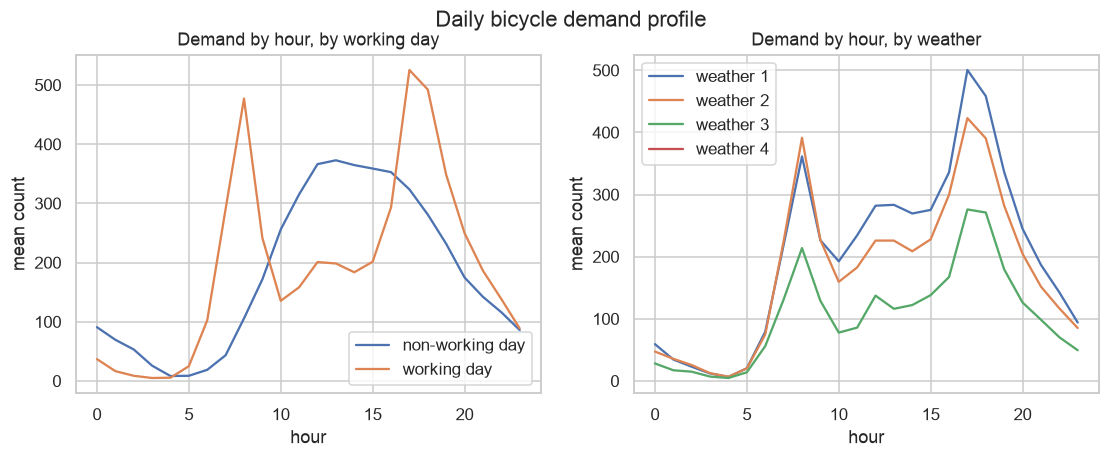

Task 11 passed.


In [33]:
_fig, _axes = demand_profile_figure(bikes)

assert len(_axes) == 2, f"expected two panels, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_legend() is not None, f"panel {_i} has no legend"
    assert len(_ax.lines) >= 2, f"panel {_i} should have at least two lines"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), "the figure has no suptitle"
assert len(_axes[0].lines) == 2, "the left panel compares exactly two groups"

plt.show()
print("Task 11 passed.")

### Question 8 — pooling and conditioning

**(a)** Draw the *pooled* profile as well: mean `cnt` by `hr` with no
conditioning. Compare it with your two-line left panel. Describe a
statement about commuter behaviour that the pooled figure would support
and that is false for both of the underlying groups.

**(b)** This is the same phenomenon as Practice 2 §12. Name it, and state
the general rule it implies about reporting an aggregate.

In [ ]:
# Space for the code that supports your answer.

**Your answer:**

The pooled profile is a single average demand curve across all days. It smooths over the fact that working days and non-working days have very different structures: the left panel shows a strong commuter pattern, with a morning rise around 08:00 and an evening peak around 17:00-18:00, while the weekend pattern is flatter and more recreational. A pooled curve can easily suggest a single “typical” daily rhythm that is false for both groups, for example a morning commuting bump that does not exist on weekends. That is the classic pooling paradox: the aggregate can create a pattern that is absent in each subgroup because the two groups are mixed together.

This is Simpson’s paradox / aggregation bias. The general rule is simple: if a group variable matters for the response, an aggregate can hide or even reverse the subgroup pattern. Whenever the data come from several subpopulations with different distributions, reporting only the pooled average is misleading unless the conditioning variable is explicitly shown.

## 13. Task 12 — Open-ended

No assert. Marked on the written analysis.

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Read that table first: four of the columns are integer-coded categories,
four are physical measurements that the publisher divided by a constant,
one is a date stored as text, and `casual + registered` equals `cnt`
exactly.

**Produce a short data-quality and structure report on this table.** Cover
at least:

1. **Types.** Which columns does pandas infer wrongly, in the sense that
   the inferred type permits an operation that is meaningless? Fix them
   and show one operation that becomes an error after your fix.
2. **Units.** Restore the four normalised columns to physical units and
   sanity-check the resulting ranges against what you know about
   Washington D.C. Report anything that looks wrong.
3. **The date.** Parse `dteday`. Confirm the series is complete: is there
   one row for every hour of every day in the range? If rows are missing,
   how many, and does their absence look random?
4. **A correlation you should not compute.** Produce the correlation
   matrix of the numeric columns, then identify at least two entries in it
   that are meaningless or misleading, and say why. At least one of your
   examples must be about an integer-coded category.
5. **Leakage.** Explain why `casual` and `registered` must not be used as
   features to predict `cnt`. Then describe a realistic prediction task
   for this dataset in which using them *would* be legitimate.
6. **A recommendation.** In one paragraph: which columns would you hand to
   a model that predicts hourly demand, and which would you exclude and
   why. Practice 3 §4 fits that model, so this is a real handover.

A good answer distinguishes "wrong" from "misleading" and says which of
its findings would actually change a modelling decision.

In [ ]:
# Your analysis. Add as many cells as you need.

**Your write-up:**

This table is mostly clean but it contains several traps. The integer-coded category columns are `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday` and `weathersit`; pandas infers them as numbers, which makes calculations like `season.mean()` or `hr + 1` look valid even though they are meaningless for unordered or ordinal-coded categories. I would convert them to `category` (with a defined order only for genuinely ordered cases such as `weathersit`, `season` if treated as ordered or `hr` if order is meaningful but not linear) and then use a `datetime` conversion for `dteday`. After the fix, an operation like `bikes['season'] + 1` raises a type error, which is exactly what we want: the data are now represented as categories, not as numbers with a fake metric.

The four normalised columns are `temp`, `atemp`, `hum` and `windspeed`, and they should be restored by multiplying by 41, 50, 100 and 67 respectively. The recovered ranges are about 0.82-41°C for `temp`, 0-50°C for `atemp`, 0-100% for `hum`, and 0-57 km/h for `windspeed`. Those are plausible for Washington D.C. and check out with the dataset’s provenance: cold winter nights and warm summer days are both represented, and the zero values for wind/humidity are credible weather minima. Nothing here looks obviously wrong.

The date column is complete enough to support a daily time series but not perfectly complete at the hourly level. The range is 2011-01-01 to 2012-12-31, which is 731 days, and the dataset has 17,379 rows; the expected total is 731 × 24 = 17,544, so there are 165 missing hourly records. There are no missing days entirely, but there are many dates with fewer than 24 entries; that does not look like a random missingness pattern but like a sparse set of hourly gaps, which is plausible for a real operational log. The date field should therefore be parsed with `pd.to_datetime` before any time-based modelling.

A correlation matrix of the numeric columns is useful for EDA but not for interpreting all of its entries. Some cells are actively misleading because the variables are integer-coded categories rather than measured continuous quantities. For example, `season` vs `mnth` has a correlation of about 0.83, but it is not a substantive “relationship” between two real scientific measurements; it is a calendar artifact produced by the same annual cycle being encoded twice in different ways. Similarly, `holiday` vs `workingday` is about -0.25, which is a coding artifact of the schedule rather than a meaningful economic quantity. These values should not be interpreted as causal or geometric relationships in the same way as correlations between physical variables like `temp` and `cnt`.

`casual` and `registered` must be excluded as features when predicting `cnt` because they sum exactly to `cnt`: using them as explanatory variables leaks the target. In effect, the model would be given the decomposition of the outcome itself, which makes almost any forecast look artificially good. A legitimate use of these columns would be a separate forecasting task for `casual` or `registered` themselves, such as predicting next-hour non-registered or registered rentals from past weather and calendar data, where the target is one component and not the total.

For a model that predicts hourly demand, I would hand in `hr`, `workingday`, `weekday`, `holiday`, `season`, `mnth`, `weathersit`, `temp`, `atemp`, `hum`, `windspeed`, and perhaps a transformed `dteday` such as day-of-year or weekend indicator. I would exclude `instant` and the raw date string because they are record identifiers, not predictive signal, and I would also exclude `casual` and `registered` because they are target leakage. The modelling decision that matters most is not the exact integer coding of the category variables but whether they are used in a way that respects their semantics: calendar and weather variables are useful and interpretable, while decomposition columns of the target are not.

## 14. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced.
- Task 12 has a written report, not only code.